1. Veriyi oku
2. column_summary tablosunu çıkar
3. text length analizi yap
4. product dağılımını gör
5. issue dağılımını gör
6. tags alanına bak
7. model_df oluştur
8. küçük sınıfları filtrele
9. processed CSV olarak kaydet

# 01 — CFPB Complaint Data: Initial EDA

# 03 — Baseline Product Classification

## Purpose

This notebook builds the first baseline machine learning model for complaint classification.

The task is:

Complaint narrative → Product category

We start with a simple and explainable baseline:

- TF-IDF vectorisation
- Logistic Regression classifier
- Train/test split
- Precision, recall, F1-score evaluation
- Confusion matrix review

This baseline will be used later to compare against transformer-based models such as DistilBERT.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
from pathlib import Path

processed_path = Path("../data/processed/cfpb_product_classification_sample.csv")
raw_path = Path("../data/raw/cfpb_complaints_narratives_1000.csv")

print("Processed exists:", processed_path.exists())
print("Raw exists:", raw_path.exists())

Processed exists: True
Raw exists: True


In [5]:
DATA_PATH = Path("../data/processed/cfpb_product_classification_sample.csv")

model_df = pd.read_csv(DATA_PATH)

print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

model_df.head()

Rows: 984
Columns: 2


,text,label
0,"This complaint concerns continued collection efforts relating to a disputed towing/storage deficiency balance allegedly owed to XXXX XXXX XXXX XXXX .\n\nAfter my original CFPB complaint, the colle...",Debt collection
1,"XXXX XXXX, the third-party company responsible for processing and disbursing student refunds on behalf of XXXX University , issued a direct deposit refund in the amount of approximately {$10000.00...",Checking or savings account
2,I received a call from XXXX XXXX impersonating an officer of the court with legal XXXX XXXX XXXX documents. They were attempting to come to my residents I contacted Citibank who had no record of d...,Debt collection
3,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, CA XXXX ( XXXX ) XXXX XXXX Date : XX/XX/XXXX Wells Fargo XXXX Department Re : Request for Reconsideration of Denied Debit Card Fraud Claim Claim Number : XXXX A...",Checking or savings account
4,"XXXX I need you XXXX XXXX, to put it in writing that you state that NO MONEY ( none of my money over the XXXX ) can be withdrawn from my Edge account for the XXXX Days after the NEW MONEY is depo...",Checking or savings account


# 03_baseline_classification.ipynb
## Siradaki Adimlar 
1. Classification datasını oku
2. label dağılımına bak
3. train/test split yap
4. TF-IDF ile metni sayıya çevir
5. Logistic Regression eğit
6. classification_report ile precision/recall/F1 ölç
7. confusion matrix ile model nerede karışıyor gör
8. sonuçları yorumla

In [6]:
label_counts = model_df["label"].value_counts()

print("Number of classes:", model_df["label"].nunique())
print("Total rows:", len(model_df))

label_counts

Number of classes: 8
Total rows: 984


label
Debt collection                                            299
Checking or savings account                                260
Credit card                                                209
Mortgage                                                    85
Vehicle loan or lease                                       49
Money transfer, virtual currency, or money service          31
Credit reporting or other personal consumer reports         28
Payday loan, title loan, personal loan, or advance loan     23
Name: count, dtype: int64

In [7]:
label_distribution = pd.DataFrame({
    "count": model_df["label"].value_counts(),
    "percent": (model_df["label"].value_counts(normalize=True) * 100).round(2)
})

label_distribution

,count,percent
label,,
Debt collection,299,30.39
Checking or savings account,260,26.42
Credit card,209,21.24
Mortgage,85,8.64
Vehicle loan or lease,49,4.98
"Money transfer, virtual currency, or money service",31,3.15
Credit reporting or other personal consumer reports,28,2.85
"Payday loan, title loan, personal loan, or advance loan",23,2.34


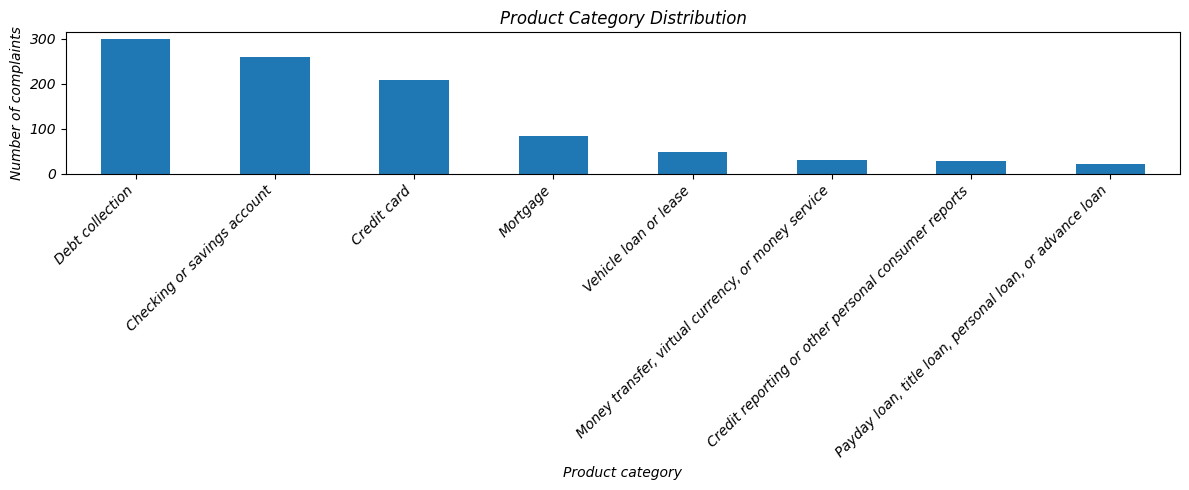

In [8]:
label_counts.plot(
    kind="bar",
    figsize=(12, 5),
    title="Product Category Distribution"
)

plt.xlabel("Product category")
plt.ylabel("Number of complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train size: 787
Test size: 197

Train label distribution:
label
Debt collection                                            0.304
Checking or savings account                                0.264
Credit card                                                0.212
Mortgage                                                   0.086
Vehicle loan or lease                                      0.050
Money transfer, virtual currency, or money service         0.032
Credit reporting or other personal consumer reports        0.028
Payday loan, title loan, personal loan, or advance loan    0.024
Name: proportion, dtype: float64

Test label distribution:
label
Debt collection                                            0.305
Checking or savings account                                0.264
Credit card                                                0.213
Mortgage                                                   0.086
Vehicle loan or lease                                      0.051
Money transfer, virtual cu

In [10]:
split_check = pd.DataFrame({
    "full_data_percent": y.value_counts(normalize=True).round(3),
    "train_percent": y_train.value_counts(normalize=True).round(3),
    "test_percent": y_test.value_counts(normalize=True).round(3),
})

split_check

,full_data_percent,train_percent,test_percent
label,,,
Debt collection,0.304,0.304,0.305
Checking or savings account,0.264,0.264,0.264
Credit card,0.212,0.212,0.213
Mortgage,0.086,0.086,0.086
Vehicle loan or lease,0.050,0.050,0.051
"Money transfer, virtual currency, or money service",0.032,0.032,0.030
Credit reporting or other personal consumer reports,0.028,0.028,0.030
"Payday loan, title loan, personal loan, or advance loan",0.023,0.024,0.020


## Train/Test Split Check

The dataset was split into 80% training and 20% testing data.

A stratified split was used to preserve the original product category distribution across both sets. This is important because the dataset is imbalanced, with the top three product categories representing most of the sample.

The split check confirms that class proportions are almost identical across the full dataset, training set, and test set.

In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [12]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (787, 5000)
X_test_tfidf shape: (197, 5000)


In [13]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("First 50 features:")
print(feature_names[:50])

Number of TF-IDF features: 5000
First 50 features:
['00' '00 1000' '00 account' '00 balance' '00 bank' '00 bonus' '00 charge'
 '00 charges' '00 collection' '00 credit' '00 date' '00 despite'
 '00 dispute' '00 fee' '00 late' '00 month' '00 payment' '00 posted'
 '00 refund' '00 remaining' '00 time' '00 total' '00 transaction'
 '00 transfer' '00 unauthorized' '00 wire' '00 xx' '00 xxxx' '10' '10 00'
 '10 business' '10 days' '10 years' '100' '100 00' '100 accurate'
 '100 time' '100 xxxx' '1000' '1000 00' '10000' '10000 00' '1005' '1006'
 '1006 34' '101' '1024' '1024 35' '1024 38' '1024 40']


In [14]:
# Logistic Regression modelini oluştur.
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Baseline Logistic Regression model created.")

Baseline Logistic Regression model created.


In [15]:
baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [17]:
y_pred = baseline_model.predict(X_test_tfidf)

print("Predictions created.")
print("Number of predictions:", len(y_pred))
print("First 10 predictions:")
print(y_pred[:10])

Predictions created.
Number of predictions: 197
First 10 predictions:
['Debt collection' 'Mortgage' 'Checking or savings account'
 'Checking or savings account' 'Checking or savings account' 'Mortgage'
 'Debt collection' 'Debt collection' 'Checking or savings account'
 'Checking or savings account']


In [18]:
report = classification_report(
    y_test,
    y_pred,
    digits=3
)

print(report)

                                                         precision    recall  f1-score   support

                            Checking or savings account      0.782     0.827     0.804        52
                                            Credit card      0.892     0.786     0.835        42
    Credit reporting or other personal consumer reports      0.556     0.833     0.667         6
                                        Debt collection      0.981     0.867     0.920        60
     Money transfer, virtual currency, or money service      0.333     0.333     0.333         6
                                               Mortgage      0.680     1.000     0.810        17
Payday loan, title loan, personal loan, or advance loan      0.000     0.000     0.000         4
                                  Vehicle loan or lease      0.800     0.800     0.800        10

                                               accuracy                          0.812       197
                            

In [19]:
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    digits=3
)

report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
Checking or savings account,0.781818,0.826923,0.803738,52.000000
Credit card,0.891892,0.785714,0.835443,42.000000
Credit reporting or other personal consumer reports,0.555556,0.833333,0.666667,6.000000
Debt collection,0.981132,0.866667,0.920354,60.000000
"Money transfer, virtual currency, or money service",0.333333,0.333333,0.333333,6.000000
Mortgage,0.680000,1.000000,0.809524,17.000000
"Payday loan, title loan, personal loan, or advance loan",0.000000,0.000000,0.000000,4.000000
Vehicle loan or lease,0.800000,0.800000,0.800000,10.000000
accuracy,0.812183,0.812183,0.812183,0.812183
macro avg,0.627966,0.680746,0.646132,197.000000


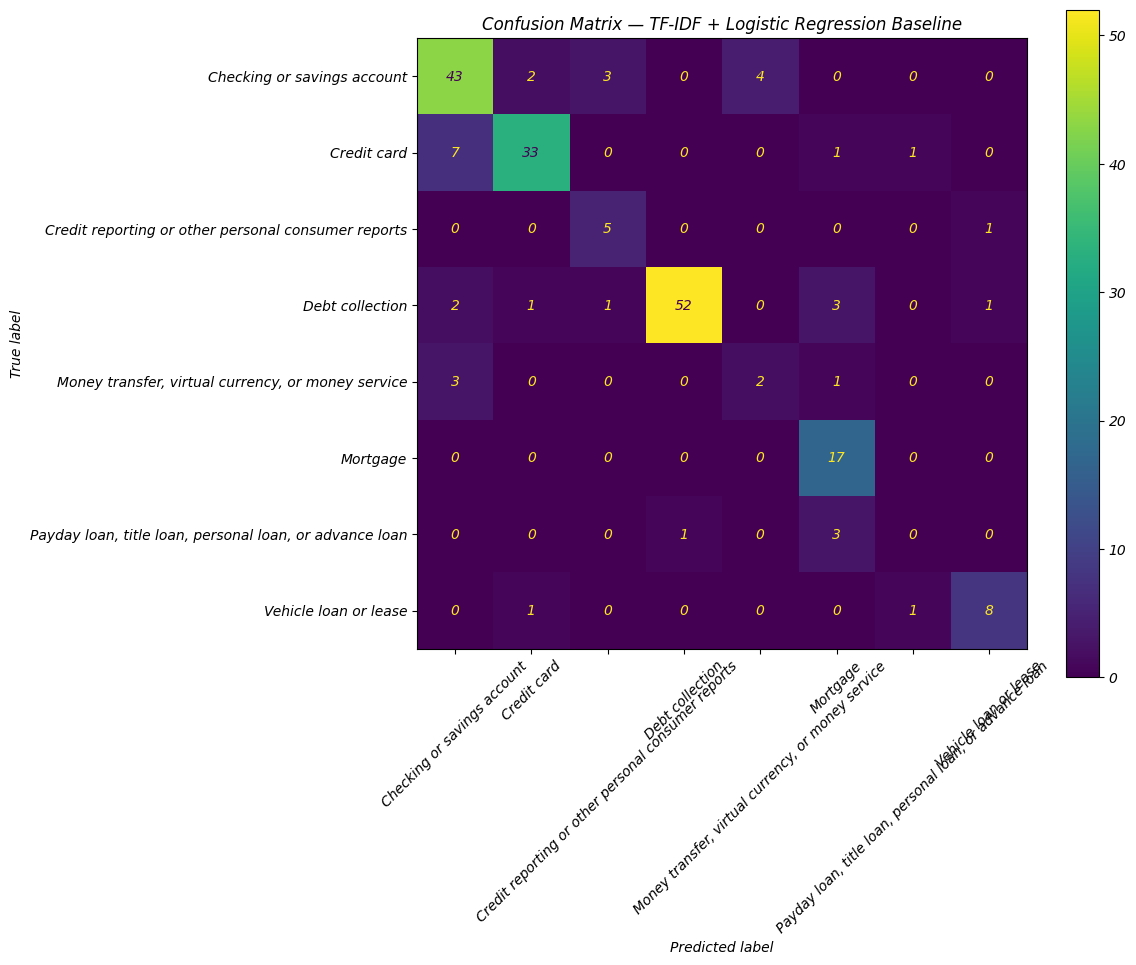

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.title("Confusion Matrix — TF-IDF + Logistic Regression Baseline")
plt.tight_layout()
plt.show()

## Baseline Model Interpretation

The TF-IDF + Logistic Regression baseline achieved 81.2% accuracy and a weighted F1-score of 0.812 on the test set.

Performance was strongest for high-support categories such as Debt collection, Credit card, Checking or savings account, Mortgage, and Vehicle loan or lease.

However, the macro F1-score was lower at 0.646, showing that the model struggled on smaller classes. In particular, the Payday loan / title loan / personal loan category had only 4 test examples and was not correctly predicted.

This confirms that the baseline is useful but not sufficient for all complaint categories. The next improvement steps are:
- collect or sample more examples for minority classes,
- tune TF-IDF and Logistic Regression hyperparameters,
- compare against transformer models such as DistilBERT,
- review misclassified examples to understand semantic overlap between categories.

In [21]:
error_analysis_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})

error_analysis_df["is_correct"] = error_analysis_df["true_label"] == error_analysis_df["predicted_label"]

misclassified_df = error_analysis_df[~error_analysis_df["is_correct"]].copy()

print("Total test examples:", len(error_analysis_df))
print("Correct predictions:", error_analysis_df["is_correct"].sum())
print("Incorrect predictions:", len(misclassified_df))

misclassified_df.head(10)

Total test examples: 197
Correct predictions: 160
Incorrect predictions: 37


,text,true_label,predicted_label,is_correct
5,"This complaint is against Monterey Financial Services, XXXX as holder of a consumer credit contract under the FTC Holder in Due Course Rule, 16 C.F.R. 433.2. The underlying transaction giving rise...","Payday loan, title loan, personal loan, or advance loan",Mortgage,False
8,"To Whom It May Concern, I have a {$5000.00} credit balance on a credit card that is serviced by Wells Fargo, and they won't send me my money. This is now an ongoing issue with Wells Fargo Bank tha...",Credit card,Checking or savings account,False
22,I am submitting a complaint regarding Wells Fargos handling of a fraud dispute involving my credit card account.\n\nWells Fargo denied my fraud claim and subsequent appeal despite substantial thir...,Credit card,Checking or savings account,False
25,just awaiting letter or email of settlement satisfaction,Credit card,"Payday loan, title loan, personal loan, or advance loan",False
33,"BMO Bank N.A . is wrongfully withholding {$1400.00} of my funds on an active, open credit card account.On XX/XX/year>, BMO issued a refund check for {$1400.00} due to a credit balance. I deposited...",Credit card,Checking or savings account,False
36,"I am writing to dispute the inaccurate repossession/charge-off information being reported for the account XXXX XXXX, account number ending in XXXXXXXX XXXX XXXX. After reviewing my credit report, ...",Credit reporting or other personal consumer reports,Vehicle loan or lease,False
37,ONLINE TRANSFER REF # XXXX TO WELLS FARGO ACTIVE CASH VISA CARD XXXX ON XXXX ...... {$6500.00} i did not do this,Checking or savings account,"Money transfer, virtual currency, or money service",False
39,I suffered property loss or stolen in the amount of over {$250000.00} when Wells Fargo Bank merge with XXXX XXXX in XXXX. I rented a Safe Deposit Box form XXXX after XXXX XXXX of XXXX and in XXXX...,"Money transfer, virtual currency, or money service",Checking or savings account,False
40,"Bank of America gave me a deadline to provide relative 's death certificate by XX/XX/XXXX. I have followed up with questions regarding clarifications on XX/XX/XXXX, XX/XX/XXXX, XX/XX/XXXX, XX/XX/X...","Money transfer, virtual currency, or money service",Mortgage,False
48,I am submitting this complaint regarding possible unauthorized banking activity and identity misuse associated with Wells Fargo accounts or services that I do not recognize or authorize. \n\nI bel...,Checking or savings account,Credit reporting or other personal consumer reports,False


## Error Analysis

The baseline model performs well overall, but the misclassified examples show several clear error patterns.

First, loan-related categories overlap. The model sometimes confuses payday / personal loan complaints with mortgage complaints because these narratives share terms such as loan, balance, contract, payment, and debt. This is also affected by the low number of examples in the payday / personal loan class.

Second, credit card complaints are sometimes predicted as checking or savings account complaints. This happens when consumers describe credit card disputes using general banking language such as account, funds, bank, balance, transaction, and dispute.

Third, money transfer complaints can be confused with checking or savings account complaints because money transfers are often described through bank account and funds-related language.

Fourth, credit reporting complaints can be confused with the underlying financial product mentioned in the narrative. For example, a complaint about inaccurate reporting of a repossession may be predicted as vehicle loan or lease, even though the actual product category is credit reporting.

Overall, the errors are mostly explainable and reflect semantic overlap between financial products rather than random model behaviour. The next improvement steps are to review more misclassified examples, tune the baseline model, and later compare it with transformer-based models such as DistilBERT.

In [22]:
error_pairs = (
    misclassified_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,true_label,predicted_label,count
3,Credit card,Checking or savings account,7
2,Checking or savings account,"Money transfer, virtual currency, or money service",4
12,"Money transfer, virtual currency, or money service",Checking or savings account,3
15,"Payday loan, title loan, personal loan, or advance loan",Mortgage,3
1,Checking or savings account,Credit reporting or other personal consumer reports,3
10,Debt collection,Mortgage,3
0,Checking or savings account,Credit card,2
7,Debt collection,Checking or savings account,2
16,Vehicle loan or lease,Credit card,1
14,"Payday loan, title loan, personal loan, or advance loan",Debt collection,1


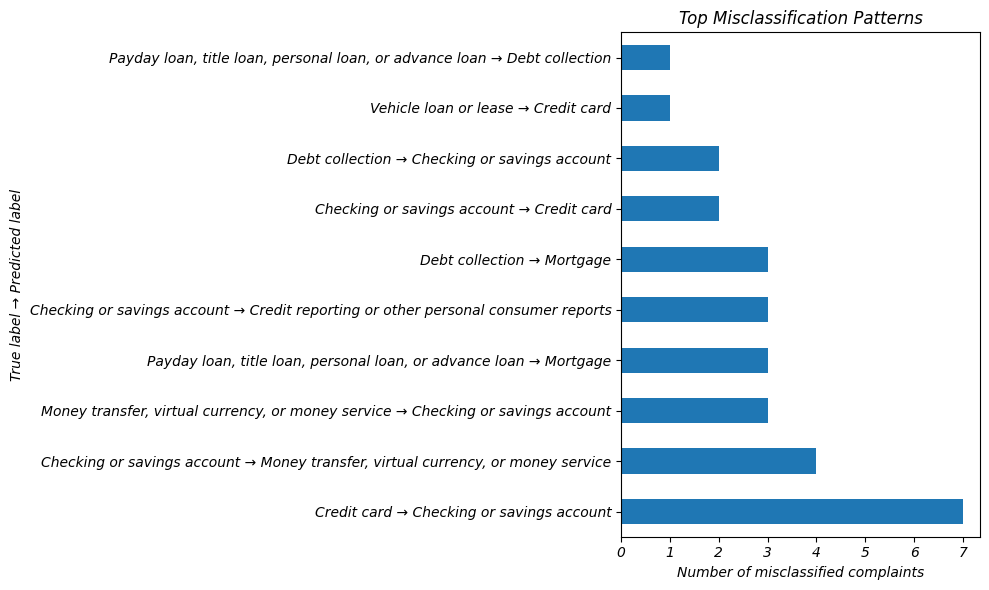

In [23]:
top_error_pairs = error_pairs.head(10).copy()

top_error_pairs["error_pair"] = (
    top_error_pairs["true_label"] + " → " + top_error_pairs["predicted_label"]
)

top_error_pairs.plot(
    kind="barh",
    x="error_pair",
    y="count",
    figsize=(10, 6),
    legend=False,
    title="Top Misclassification Patterns"
)

plt.xlabel("Number of misclassified complaints")
plt.ylabel("True label → Predicted label")
plt.tight_layout()
plt.show()

In [24]:
correct_df = error_analysis_df[error_analysis_df["is_correct"]].copy()

correct_df.head(10)

,text,true_label,predicted_label,is_correct
0,There was a debt that we just paid off last week. Sunrise credit has continued to call and harass my daughter. They called again didn't verify any info and released the info to my daughter.,Debt collection,Debt collection,True
1,"Wells fargo they were no longer involved with the XXXX XXXXXXXX were no longer contacting the court sincw XXXX XXXX \nXXXX XXXX XXXX, and constitutes a false representation to the court. This is a...",Mortgage,Mortgage,True
2,"To Whom It May Concern, I am writing to formally express my extreme disappointment and concern regarding the treatment I recently experienced at XXXX separate Bank of America locations in Georgia ...",Checking or savings account,Checking or savings account,True
3,On XX/XX/XXXX I made a purchase on XXXX for an item that was returnable. After receiving this order I immediately tried to initiate a return. XXXX was showing the item was non returnable after the...,Checking or savings account,Checking or savings account,True
4,Back in XXXX Fultons bank offered XXXX for opening a simply checking account. Did it On line and followed all rules. Called them time after time and they cant find anything! Called again now they ...,Checking or savings account,Checking or savings account,True
6,"On XX/XX/year>, I paid in full a {$190.00} debt held by Sunrise Credit Services, related to a former XXXX account. I received a paid-in-full letter from Sunrise on XX/XX/year>, after calling them ...",Debt collection,Debt collection,True
7,On XX/XX/year> notification was sent to the collector to verify the debt. I never received any response from the company.,Debt collection,Debt collection,True
9,Unauthorized Electronic Fund Transfers Following Wells Fargo Impersonation Scam and Account Takeover Product : Checking Account / Electronic Fund Transfer Issue Fraud / Unauthorized Transactions/ ...,Checking or savings account,Checking or savings account,True
10,I am filing this complaint regarding XXXX XXXX XXXX and U.S. Bank in connection with the XXXX XXXX XXXX property insurance claim and mortgage servicing obligations. \n\nXXXX XXXX committed on Thur...,Mortgage,Mortgage,True
11,I tried to close my bank account on XX/XX/year> for the first time and then I tried to close it multiple times after that with the last attempt being XX/XX/XXXX or XXXX. I have records of these ca...,Checking or savings account,Checking or savings account,True


In [25]:
y_proba = baseline_model.predict_proba(X_test_tfidf)

max_proba = y_proba.max(axis=1)

error_analysis_df["confidence"] = max_proba

error_analysis_df[["text", "true_label", "predicted_label", "is_correct", "confidence"]].head()

,text,true_label,predicted_label,is_correct,confidence
0,There was a debt that we just paid off last week. Sunrise credit has continued to call and harass my daughter. They called again didn't verify any info and released the info to my daughter.,Debt collection,Debt collection,True,0.314698
1,"Wells fargo they were no longer involved with the XXXX XXXXXXXX were no longer contacting the court sincw XXXX XXXX \nXXXX XXXX XXXX, and constitutes a false representation to the court. This is a...",Mortgage,Mortgage,True,0.337748
2,"To Whom It May Concern, I am writing to formally express my extreme disappointment and concern regarding the treatment I recently experienced at XXXX separate Bank of America locations in Georgia ...",Checking or savings account,Checking or savings account,True,0.305686
3,On XX/XX/XXXX I made a purchase on XXXX for an item that was returnable. After receiving this order I immediately tried to initiate a return. XXXX was showing the item was non returnable after the...,Checking or savings account,Checking or savings account,True,0.483581
4,Back in XXXX Fultons bank offered XXXX for opening a simply checking account. Did it On line and followed all rules. Called them time after time and they cant find anything! Called again now they ...,Checking or savings account,Checking or savings account,True,0.283626


In [26]:
confidence_summary = (
    error_analysis_df
    .groupby("is_correct")["confidence"]
    .describe()
)

confidence_summary

,count,mean,std,min,25%,50%,75%,max
is_correct,,,,,,,,
False,37.0,0.273326,0.074013,0.171726,0.207844,0.258503,0.331749,0.411225
True,160.0,0.459899,0.192032,0.180996,0.316797,0.412261,0.584187,0.854494


In [27]:
low_confidence_df = error_analysis_df[error_analysis_df["confidence"] < 0.60].copy()

print("Low-confidence predictions:", len(low_confidence_df))
print("Share of test set:", round(len(low_confidence_df) / len(error_analysis_df) * 100, 2), "%")

low_confidence_df[["text", "true_label", "predicted_label", "is_correct", "confidence"]].head(10)

Low-confidence predictions: 160
Share of test set: 81.22 %


,text,true_label,predicted_label,is_correct,confidence
0,There was a debt that we just paid off last week. Sunrise credit has continued to call and harass my daughter. They called again didn't verify any info and released the info to my daughter.,Debt collection,Debt collection,True,0.314698
1,"Wells fargo they were no longer involved with the XXXX XXXXXXXX were no longer contacting the court sincw XXXX XXXX \nXXXX XXXX XXXX, and constitutes a false representation to the court. This is a...",Mortgage,Mortgage,True,0.337748
2,"To Whom It May Concern, I am writing to formally express my extreme disappointment and concern regarding the treatment I recently experienced at XXXX separate Bank of America locations in Georgia ...",Checking or savings account,Checking or savings account,True,0.305686
3,On XX/XX/XXXX I made a purchase on XXXX for an item that was returnable. After receiving this order I immediately tried to initiate a return. XXXX was showing the item was non returnable after the...,Checking or savings account,Checking or savings account,True,0.483581
4,Back in XXXX Fultons bank offered XXXX for opening a simply checking account. Did it On line and followed all rules. Called them time after time and they cant find anything! Called again now they ...,Checking or savings account,Checking or savings account,True,0.283626
5,"This complaint is against Monterey Financial Services, XXXX as holder of a consumer credit contract under the FTC Holder in Due Course Rule, 16 C.F.R. 433.2. The underlying transaction giving rise...","Payday loan, title loan, personal loan, or advance loan",Mortgage,False,0.193845
6,"On XX/XX/year>, I paid in full a {$190.00} debt held by Sunrise Credit Services, related to a former XXXX account. I received a paid-in-full letter from Sunrise on XX/XX/year>, after calling them ...",Debt collection,Debt collection,True,0.393135
7,On XX/XX/year> notification was sent to the collector to verify the debt. I never received any response from the company.,Debt collection,Debt collection,True,0.302743
8,"To Whom It May Concern, I have a {$5000.00} credit balance on a credit card that is serviced by Wells Fargo, and they won't send me my money. This is now an ongoing issue with Wells Fargo Bank tha...",Credit card,Checking or savings account,False,0.318614
9,Unauthorized Electronic Fund Transfers Following Wells Fargo Impersonation Scam and Account Takeover Product : Checking Account / Electronic Fund Transfer Issue Fraud / Unauthorized Transactions/ ...,Checking or savings account,Checking or savings account,True,0.434372


In [28]:
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60]

threshold_results = []

for threshold in thresholds:
    flagged = error_analysis_df["confidence"] < threshold
    
    total_flagged = flagged.sum()
    flagged_share = total_flagged / len(error_analysis_df)
    
    flagged_errors = ((flagged) & (~error_analysis_df["is_correct"])).sum()
    total_errors = (~error_analysis_df["is_correct"]).sum()
    
    error_capture_rate = flagged_errors / total_errors if total_errors > 0 else 0
    
    threshold_results.append({
        "threshold": threshold,
        "flagged_count": total_flagged,
        "flagged_share": round(flagged_share, 3),
        "errors_captured": flagged_errors,
        "total_errors": total_errors,
        "error_capture_rate": round(error_capture_rate, 3)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,flagged_count,flagged_share,errors_captured,total_errors,error_capture_rate
0,0.25,35,0.178,15,37,0.405
1,0.30,51,0.259,22,37,0.595
2,0.35,89,0.452,29,37,0.784
3,0.40,110,0.558,34,37,0.919
4,0.45,130,0.660,37,37,1.000
5,0.50,142,0.721,37,37,1.000
6,0.60,160,0.812,37,37,1.000


## Confidence and Human Review Threshold

The baseline model outputs a probability score for each predicted class. Correct predictions had a higher average confidence than incorrect predictions, which suggests that confidence can be useful for routing uncertain cases to human review.

However, a fixed threshold of 0.60 was too strict for this baseline model and flagged most of the test set. This is likely because TF-IDF + Logistic Regression probabilities are not fully calibrated, especially with class weighting.

Instead of treating confidence as a final business rule, I evaluated multiple thresholds to understand the trade-off between automation rate and error capture.

In a regulated financial services setting, this threshold would be chosen based on risk appetite, operational capacity, and the cost of incorrect triage.

In [29]:
final_metrics = {
    "model": "TF-IDF + Logistic Regression",
    "test_accuracy": report_dict["accuracy"],
    "macro_f1": report_dict["macro avg"]["f1-score"],
    "weighted_f1": report_dict["weighted avg"]["f1-score"],
    "test_size": len(y_test),
    "num_classes": y.nunique(),
    "num_features": X_train_tfidf.shape[1]
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df

,model,test_accuracy,macro_f1,weighted_f1,test_size,num_classes,num_features
0,TF-IDF + Logistic Regression,0.812183,0.646132,0.811503,197,8,5000


In [30]:
RESULTS_DIR = Path("../reports")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

report_df.to_csv(RESULTS_DIR / "baseline_classification_report.csv")
error_pairs.to_csv(RESULTS_DIR / "baseline_error_pairs.csv", index=False)
threshold_df.to_csv(RESULTS_DIR / "baseline_confidence_threshold_analysis.csv", index=False)
final_metrics_df.to_csv(RESULTS_DIR / "baseline_final_metrics.csv", index=False)

print("Baseline reports saved to reports/ folder.")

Baseline reports saved to reports/ folder.
